# Statistik mit Python

**Einführung anhand von Messdaten eines Web-Systems**

In diesem Notebook werden grundlegende Verfahren der deskriptiven Statistik mit Python angewendet. Im Mittelpunkt stehen die statistischen Fragestellungen; Python dient zur Aufbereitung, Auswertung und grafischen Darstellung der Daten.

## Lernziele

Nach der Bearbeitung des Notebooks können Sie

- Grundgesamtheit, Merkmale und Ausprägungen eines Datensatzes benennen,
- nominalskalierte und metrisch skalierte Merkmale unterscheiden,
- Daten auswählen, filtern und gruppieren,
- absolute und relative Häufigkeiten bestimmen,
- arithmetisches Mittel, Median, Quartile, Interquartilsabstand und empirische Standardabweichung berechnen und interpretieren,
- Säulendiagramm, Histogramm, Boxplot und Streudiagramm sachgerecht einsetzen,
- den Pearson-Korrelationskoeffizienten interpretieren,
- deskriptive Aussagen von kausalen Aussagen unterscheiden und
- die zufällige Schwankung von Stichprobenmittelwerten erläutern.

Eine Code-Zelle wird mit **Shift + Enter** ausgeführt.

## Fragestellungen

Wir betrachten Messdaten eines fiktiven Web-Systems. Jede Zeile des Datensatzes beschreibt einen API-Request.

1. Welche Endpoints werden häufig aufgerufen?
2. Wie unterscheiden sich die Antwortzeiten zwischen den Endpoints?
3. Wie sind die Antwortzeiten verteilt und wie stark streuen sie?
4. Besteht ein linearer Zusammenhang zwischen Payload-Größe und Antwortzeit?
5. Unterscheiden sich die Antwortzeiten bei Requests mit und ohne Cache-Hit?
6. Wie stark schwankt das arithmetische Mittel zwischen verschiedenen Zufallsstichproben?

## 1. Untersuchungsgegenstand und Merkmale

Ein **API-Request** ist eine Anfrage eines Programms an einen Server. Ein **Endpoint** bezeichnet die angesprochene Funktion der Schnittstelle, beispielsweise `/search` oder `/checkout`. Die **Payload** ist die übertragene Datenmenge. Ein **Cache** ist ein Zwischenspeicher; bei einem **Cache-Hit** können bereits gespeicherte Daten verwendet werden.

Die Variablen im Datensatz haben folgende Bedeutung:

| Variable | Bedeutung |
|---|---|
| `request_id` | Kennung des Requests |
| `endpoint` | angesprochener API-Endpoint |
| `region` | Region des Requests |
| `hour` | Stunde des Tages |
| `cache_hit` | gibt an, ob Daten aus dem Cache verwendet wurden |
| `payload_kb` | Payload-Größe in Kilobyte |
| `response_ms` | Antwortzeit in Millisekunden |
| `status_code` | HTTP-Statuscode, z. B. 200, 404 oder 500 |

### Grundbegriffe

- **Grundgesamtheit:** die Gesamtheit der für die Untersuchung interessanten Daten liefernden Objekte; hier können das die interessierenden API-Requests sein.
- **Merkmal:** eine für die Untersuchung interessante Eigenschaft eines solchen Objekts, z. B. Antwortzeit oder Endpoint.
- **Ausprägung:** ein beobachteter Wert eines Merkmals.
- **Wertemenge:** die Menge aller möglichen Ausprägungen eines Merkmals.
- **Stichprobe:** die tatsächlich untersuchte Teilmenge der Grundgesamtheit.

Die 320 Zeilen bilden zunächst die vorliegenden Beobachtungsdaten. Ob diese Daten als Stichprobe einer größeren Grundgesamtheit aufgefasst werden können, hängt von der Fragestellung und der Art der Datenerhebung ab.

### Merkmalsskalierungen

- `endpoint`, `region`, `cache_hit` und `status_code` sind **nominalskaliert**.
- `payload_kb` und `response_ms` sind **metrisch skaliert**.
- `hour` ist eine diskrete Zeitangabe und wird im Folgenden nicht für Lage- oder Streuungsmaße verwendet.

Dass `status_code` durch Zahlen dargestellt wird, macht das Merkmal nicht metrisch. Differenzen oder Mittelwerte von HTTP-Statuscodes haben keine sinnvolle inhaltliche Interpretation.

## 2. Benötigte Python-Bibliotheken

Wir verwenden `pandas` zur Arbeit mit Tabellen, `numpy` für numerische Berechnungen und Zufallszahlen sowie `matplotlib` für grafische Darstellungen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 20)
plt.rcParams["figure.figsize"] = (8, 4.5)

/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-18licsr2 because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 3. Datensatz einlesen und prüfen

In [2]:
df = pd.read_csv("data/api_requests.csv")
df.head()

,request_id,endpoint,region,hour,cache_hit,payload_kb,response_ms,status_code
0,REQ-0001,/login,US-East,10,False,10.4,236.0,200
1,REQ-0002,/checkout,EU-West,17,False,18.5,272.5,500
2,REQ-0003,/checkout,US-East,8,False,14.3,387.5,200
3,REQ-0004,/search,EU-West,19,False,41.5,216.7,200
4,REQ-0005,/cart,EU-West,9,False,16.6,180.1,200


In [3]:
print("Anzahl Zeilen und Spalten:", df.shape)
print("Spalten:", df.columns.to_list())

Anzahl Zeilen und Spalten: (320, 8)
Spalten: ['request_id', 'endpoint', 'region', 'hour', 'cache_hit', 'payload_kb', 'response_ms', 'status_code']


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   request_id   320 non-null    object 
 1   endpoint     320 non-null    object 
 2   region       320 non-null    object 
 3   hour         320 non-null    int64  
 4   cache_hit    320 non-null    bool   
 5   payload_kb   320 non-null    float64
 6   response_ms  314 non-null    float64
 7   status_code  320 non-null    int64  
dtypes: bool(1), float64(2), int64(2), object(3)
memory usage: 17.9+ KB


Vor einer statistischen Auswertung sollte geprüft werden, ob Werte fehlen. Fehlende Werte werden nicht pauschal entfernt. Für jede Auswertung ist zu entscheiden, welche Variablen benötigt werden.

In [5]:
df.isna().sum()

request_id     0
endpoint       0
region         0
hour           0
cache_hit      0
payload_kb     0
response_ms    6
status_code    0
dtype: int64

Für Auswertungen der Antwortzeit benötigen wir Beobachtungen mit vorhandenem Wert von `response_ms`. Dafür wird ein eigener DataFrame angelegt. Bei Auswertungen anderer Merkmale kann weiterhin der vollständige Datensatz verwendet werden.

In einer realen Untersuchung müsste zusätzlich geklärt werden, weshalb Werte fehlen. Das Entfernen unvollständiger Beobachtungen kann zu Verzerrungen führen, wenn das Auftreten fehlender Werte systematisch ist.

In [6]:
response_data = df.dropna(subset=["response_ms"]).copy()

print("Alle Requests:", len(df))
print("Requests mit gemessener Antwortzeit:", len(response_data))

Alle Requests: 320
Requests mit gemessener Antwortzeit: 314


## 4. Daten auswählen und filtern

Mit Bedingungen lassen sich Teilmengen eines DataFrames auswählen.

In [7]:
# Eine Spalte auswählen
response_data["response_ms"].head()

0    236.0
1    272.5
2    387.5
3    216.7
4    180.1
Name: response_ms, dtype: float64

In [8]:
# Requests mit HTTP-Statuscode 500
server_errors = df[df["status_code"] == 500]
server_errors[["request_id", "endpoint", "response_ms", "status_code"]].head()

,request_id,endpoint,response_ms,status_code
1,REQ-0002,/checkout,272.5,500
11,REQ-0012,/product,219.6,500
36,REQ-0037,/cart,272.8,500
44,REQ-0045,/product,121.5,500
67,REQ-0068,/product,240.8,500


In [9]:
# Mehrere Bedingungen verknüpfen
slow_checkout = response_data[
    (response_data["endpoint"] == "/checkout")
    & (response_data["response_ms"] > 400)
]

slow_checkout.head()

,request_id,endpoint,region,hour,cache_hit,payload_kb,response_ms,status_code
78,REQ-0079,/checkout,US-East,11,False,26.1,410.1,200
107,REQ-0108,/checkout,US-East,10,False,15.5,443.8,200
222,REQ-0223,/checkout,US-East,17,False,14.5,400.6,200
231,REQ-0232,/checkout,US-East,11,False,22.6,415.0,200
314,REQ-0315,/checkout,US-East,20,False,18.2,413.8,500


### Übung 1: Filtern

Filtern Sie alle Requests, die

- den Endpoint `/search` verwenden,
- aus `EU-Central` stammen und
- eine Antwortzeit von mehr als 250 ms haben.

Bestimmen Sie die Anzahl dieser Requests.

Überlegen Sie anschließend: Welche Aussage beschreibt nur die vorliegenden Beobachtungen, und welche Aussage wäre bereits eine Verallgemeinerung auf eine größere Grundgesamtheit?

In [10]:
search_eu_slow = response_data[
    (response_data["endpoint"] == "/search")
    & (response_data["region"] == "EU-Central")
    & (response_data["response_ms"] > 250)
]

print("Anzahl:", len(search_eu_slow))
search_eu_slow.head()

Anzahl: 2


,request_id,endpoint,region,hour,cache_hit,payload_kb,response_ms,status_code
72,REQ-0073,/search,EU-Central,10,True,119.6,251.1,200
276,REQ-0277,/search,EU-Central,16,False,47.0,280.9,200


Die berechnete Anzahl beschreibt die vorliegenden Beobachtungen. Eine Aussage über alle zukünftigen Requests wäre eine induktive Schlussfolgerung und setzt geeignete Annahmen über die Datenerhebung voraus.

## 5. Nominalskalierte Merkmale: absolute und relative Häufigkeiten

Für die Frage nach der Nutzung der Endpoints werden alle Requests betrachtet. Fehlende Antwortzeiten spielen für diese Auswertung keine Rolle.

In [11]:
# Absolute Häufigkeiten
endpoint_counts = df["endpoint"].value_counts()
endpoint_counts

endpoint
/search      91
/product     78
/cart        54
/login       53
/checkout    44
Name: count, dtype: int64

In [12]:
# Relative Häufigkeiten in Prozent
endpoint_percent = df["endpoint"].value_counts(normalize=True) * 100
endpoint_percent.round(1)

endpoint
/search      28.4
/product     24.4
/cart        16.9
/login       16.6
/checkout    13.8
Name: proportion, dtype: float64

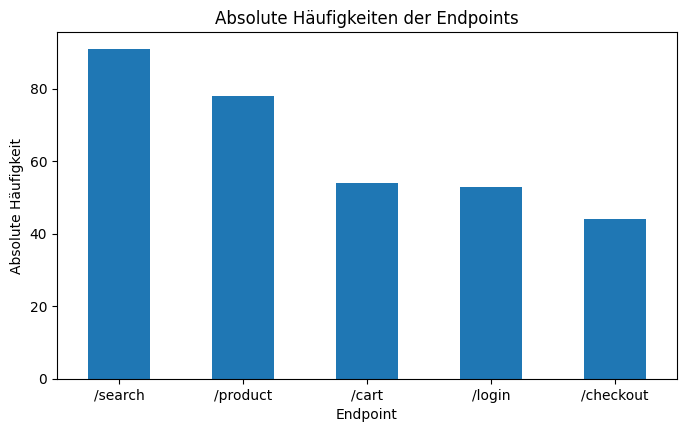

In [13]:
endpoint_counts.plot(kind="bar")
plt.title("Absolute Häufigkeiten der Endpoints")
plt.xlabel("Endpoint")
plt.ylabel("Absolute Häufigkeit")
plt.xticks(rotation=0)
plt.show()

Für nominalskalierte Merkmale sind Häufigkeitstabellen und Säulendiagramme geeignete Darstellungen. Ein Histogramm wird dagegen zur Darstellung der Verteilung eines metrisch skalierten Merkmals verwendet.

## 6. Metrisch skalierte Merkmale: Lage und Streuung

Für die Antwortzeit betrachten wir verschiedene Lage- und Streuungsmaße.

In [14]:
response_data["response_ms"].describe()

count     314.000000
mean      223.895541
std       143.965872
min        28.000000
25%       156.700000
50%       196.250000
75%       252.175000
max      1161.600000
Name: response_ms, dtype: float64

In [15]:
x = response_data["response_ms"]

q1 = x.quantile(0.25)
q3 = x.quantile(0.75)
iqr = q3 - q1

print("Arithmetisches Mittel:       ", round(x.mean(), 1), "ms")
print("Median:                      ", round(x.median(), 1), "ms")
print("empirische Standardabweichung:", round(x.std(), 1), "ms")
print("unteres Quartil:             ", round(q1, 1), "ms")
print("oberes Quartil:             ", round(q3, 1), "ms")
print("Interquartilsabstand:        ", round(iqr, 1), "ms")

Arithmetisches Mittel:        223.9 ms
Median:                       196.2 ms
empirische Standardabweichung: 144.0 ms
unteres Quartil:              156.7 ms
oberes Quartil:              252.2 ms
Interquartilsabstand:         95.5 ms


### Arithmetisches Mittel und Median

Das **arithmetische Mittel** berücksichtigt alle beobachteten Werte und reagiert deshalb empfindlich auf sehr große oder sehr kleine Beobachtungen. Der **Median** teilt die geordneten Beobachtungen so, dass mindestens 50 % der Werte kleiner oder gleich und mindestens 50 % größer oder gleich dem Median sind. Er ist gegenüber einzelnen Extremwerten robuster.

In [16]:
response_data.nlargest(8, "response_ms")[[
    "request_id", "endpoint", "region", "response_ms", "status_code"
]]

,request_id,endpoint,region,response_ms,status_code
175,REQ-0176,/cart,EU-West,1161.6,500
284,REQ-0285,/login,EU-West,1141.7,200
303,REQ-0304,/product,EU-Central,1092.7,200
214,REQ-0215,/product,EU-Central,1075.9,200
167,REQ-0168,/cart,EU-Central,1017.1,500
45,REQ-0046,/cart,EU-West,829.5,200
41,REQ-0042,/product,EU-Central,820.8,200
120,REQ-0121,/product,US-East,715.5,500


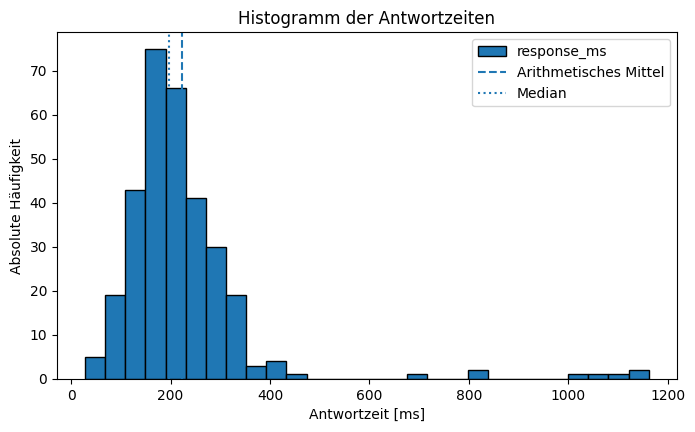

In [17]:
response_data["response_ms"].plot.hist(bins=28, edgecolor="black")
plt.axvline(response_data["response_ms"].mean(), linestyle="--", label="Arithmetisches Mittel")
plt.axvline(response_data["response_ms"].median(), linestyle=":", label="Median")
plt.title("Histogramm der Antwortzeiten")
plt.xlabel("Antwortzeit [ms]")
plt.ylabel("Absolute Häufigkeit")
plt.legend()
plt.show()

Die Verteilung ist rechtsschief. Einzelne große Antwortzeiten erhöhen das arithmetische Mittel stärker als den Median. Bei schiefen Verteilungen ist es daher sinnvoll, mehrere Lage- und Streuungsmaße gemeinsam zu betrachten.

Auch die Wahl der Klassenbreite eines Histogramms beeinflusst den visuellen Eindruck der Verteilung. Ein Histogramm sollte deshalb nicht isoliert interpretiert werden.

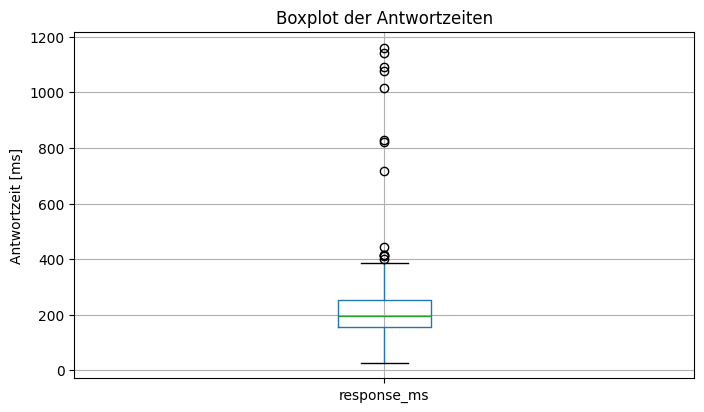

In [18]:
response_data[["response_ms"]].boxplot()
plt.title("Boxplot der Antwortzeiten")
plt.ylabel("Antwortzeit [ms]")
plt.show()

### Boxplot

Der Boxplot stellt insbesondere Median, Quartile und Interquartilsabstand dar.

- Die Linie innerhalb der Box kennzeichnet den Median.
- Die untere und obere Boxkante entsprechen dem unteren und oberen Quartil.
- Die Länge der Box entspricht dem Interquartilsabstand $IQR = Q_3-Q_1$.
- Standardmäßig werden Beobachtungen außerhalb der Grenzen $Q_1-1{,}5\cdot IQR$ und $Q_3+1{,}5\cdot IQR$ als einzelne Punkte dargestellt. Die Whisker reichen bis zu den äußersten beobachteten Werten innerhalb dieser Grenzen.

Solche Beobachtungen werden häufig als Ausreißer bezeichnet. Sie sind nicht automatisch fehlerhafte Messwerte.

## 7. Gruppenvergleich: Endpoint und Antwortzeit

Nun wird ein nominalskaliertes Merkmal (`endpoint`) gemeinsam mit einem metrisch skalierten Merkmal (`response_ms`) betrachtet.

In [19]:
endpoint_stats = (
    response_data.groupby("endpoint")["response_ms"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("median")
    .round(1)
)

endpoint_stats

,count,mean,median,std
endpoint,,,,
/login,53,166.1,148.6,147.7
/product,78,229.6,189.5,174.6
/search,88,201.8,197.1,59.3
/cart,53,250.5,207.2,197.8
/checkout,42,299.0,296.1,64.0


In der Tabelle stehen `mean` für das arithmetische Mittel und `std` für die empirische Standardabweichung.

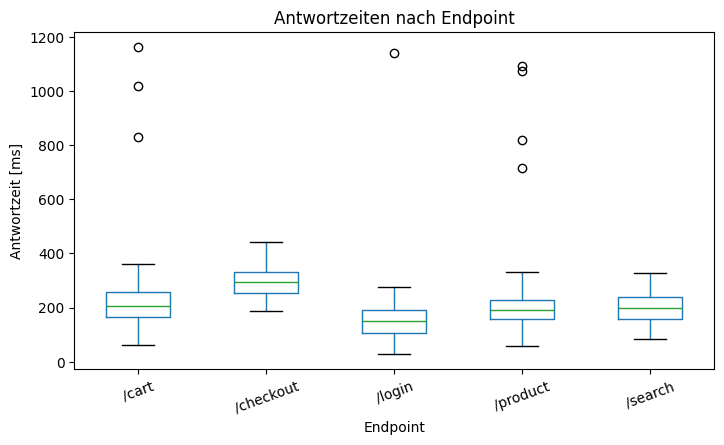

In [20]:
response_data.boxplot(column="response_ms", by="endpoint", grid=False)
plt.suptitle("")
plt.title("Antwortzeiten nach Endpoint")
plt.xlabel("Endpoint")
plt.ylabel("Antwortzeit [ms]")
plt.xticks(rotation=20)
plt.show()

### Fragen zur Auswertung

- Welcher Endpoint hat den größten Median der Antwortzeit?
- Bei welchem Endpoint ist die Streuung besonders groß?
- Bei welchen Endpoints treten Ausreißer auf?
- Unterscheiden sich arithmetisches Mittel und Median innerhalb der Gruppen deutlich?

Die Gruppenunterschiede sind zunächst deskriptive Befunde. Aus ihnen folgt noch keine Aussage über die Ursachen der Unterschiede.

## 8. Antwortzeit und Cache-Hit

Untersuchen Sie, ob sich die beobachteten Antwortzeiten zwischen Requests mit und ohne Cache-Hit unterscheiden.

Bestimmen Sie für beide Gruppen

- die Anzahl der Beobachtungen,
- das arithmetische Mittel und
- den Median der Antwortzeit.

In [21]:
cache_stats = (
    response_data.groupby("cache_hit")["response_ms"]
    .agg(["count", "mean", "median"])
    .round(1)
)
cache_stats

,count,mean,median
cache_hit,,,
False,181,250.4,221.3
True,133,187.8,172.4


Die Gruppe mit Cache-Hit weist in diesen Daten kleinere Lagewerte auf. Das ist eine deskriptive Aussage über die vorliegenden Beobachtungen.

Für eine kausale Interpretation müsste ausgeschlossen oder kontrolliert werden, dass weitere Merkmale den Gruppenunterschied erklären. Mögliche Drittvariablen sind beispielsweise Endpoint, Region, Payload-Größe oder Tageszeit.

In [22]:
pd.crosstab(df["endpoint"], df["cache_hit"], normalize="index").round(2)

cache_hit,False,True
endpoint,,
/cart,0.70,0.30
/checkout,0.89,0.11
/login,0.85,0.15
/product,0.36,0.64
/search,0.38,0.62


Die Cache-Hit-Anteile unterscheiden sich zwischen den Endpoints. Ein einfacher Vergleich der Cache-Gruppen reicht deshalb nicht aus, um die kausale Wirkung des Cachings zu bestimmen.

## 9. Zwei metrisch skalierte Merkmale: Streudiagramm und Korrelation

Wir untersuchen den Zusammenhang zwischen Payload-Größe und Antwortzeit. Zunächst wird ein Streudiagramm betrachtet.

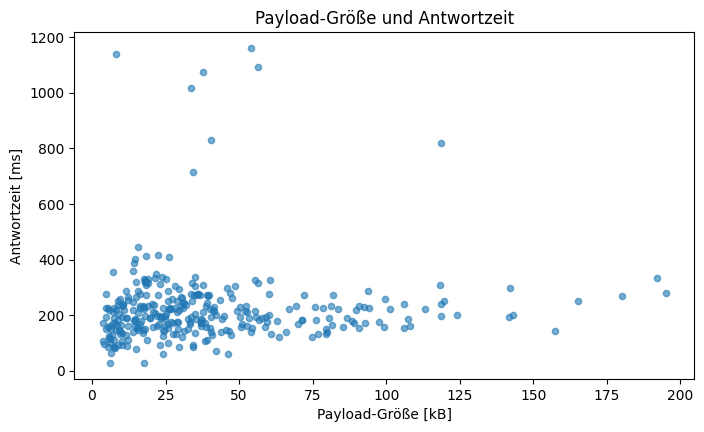

In [23]:
response_data.plot.scatter(x="payload_kb", y="response_ms", alpha=0.6)
plt.title("Payload-Größe und Antwortzeit")
plt.xlabel("Payload-Größe [kB]")
plt.ylabel("Antwortzeit [ms]")
plt.show()

In [24]:
r = response_data["payload_kb"].corr(response_data["response_ms"])
print("Pearson-Korrelationskoeffizient r_x,y:", round(r, 3))

Pearson-Korrelationskoeffizient r_x,y: 0.072


Der **Pearson-Korrelationskoeffizient** $r_{x,y}$ beschreibt Richtung und Stärke der linearen Korrelation zweier metrisch skalierter Merkmale. Es gilt $-1\le r_{x,y}\le 1$.

- $r_{x,y}=1$: perfekter positiver linearer Zusammenhang,
- $r_{x,y}=-1$: perfekter negativer linearer Zusammenhang,
- $r_{x,y}=0$: die beiden Merkmale sind linear unkorreliert.

Für die Einteilung in „schwach“, „mittel“ oder „stark“ gibt es keine allgemein gültigen Grenzwerte; die Beurteilung hängt vom Anwendungskontext ab.

Ein Wert nahe null schließt einen nichtlinearen Zusammenhang oder unterschiedliche Zusammenhänge in Teilgruppen nicht aus. Der Pearson-Korrelationskoeffizient kann außerdem empfindlich auf Ausreißer reagieren.

Aus einer Korrelation folgt keine Kausalität.

Im vorliegenden Datensatz ist der lineare Gesamtzusammenhang zwischen Payload-Größe und Antwortzeit gering. Das Ergebnis widerspricht nicht der Möglichkeit, dass innerhalb einzelner Teilgruppen andere Zusammenhänge bestehen oder weitere Merkmale die Antwortzeit beeinflussen.

In [25]:
# Optional: Pearson-Korrelation getrennt nach Endpoint
endpoint_corr = response_data.groupby("endpoint").apply(
    lambda g: g["payload_kb"].corr(g["response_ms"]),
    include_groups=False
)
endpoint_corr.rename("Korrelation").round(2).sort_values()

endpoint
/login      -0.04
/product     0.01
/checkout    0.21
/search      0.28
/cart        0.50
Name: Korrelation, dtype: float64

Die gruppenweisen Koeffizienten können sich vom Gesamtkorrelationskoeffizienten unterscheiden. Diese Auswertung eignet sich als Hinweis darauf, dass aggregierte Kennzahlen Strukturen in Teilgruppen verdecken können.

## 10. Zufällige Stichproben und Stichprobenmittelwerte

Für die folgende Simulation werden die Requests mit gemessener Antwortzeit als endliche Grundgesamtheit aufgefasst. Aus dieser Grundgesamtheit werden wiederholt einfache Zufallsstichproben ohne Zurücklegen gezogen.

Für jede Stichprobe mit Umfang $n=30$ wird das arithmetische Mittel der Antwortzeiten berechnet.

In [26]:
rng = np.random.default_rng(42)

sample_means = []
for _ in range(500):
    sample = response_data["response_ms"].sample(
        n=30,
        replace=False,
        random_state=int(rng.integers(1_000_000))
    )
    sample_means.append(sample.mean())

sample_means = pd.Series(sample_means)
sample_means.describe()

count    500.000000
mean     223.541060
std       25.460108
min      162.013333
25%      204.982500
50%      219.625000
75%      238.046667
max      321.330000
dtype: float64

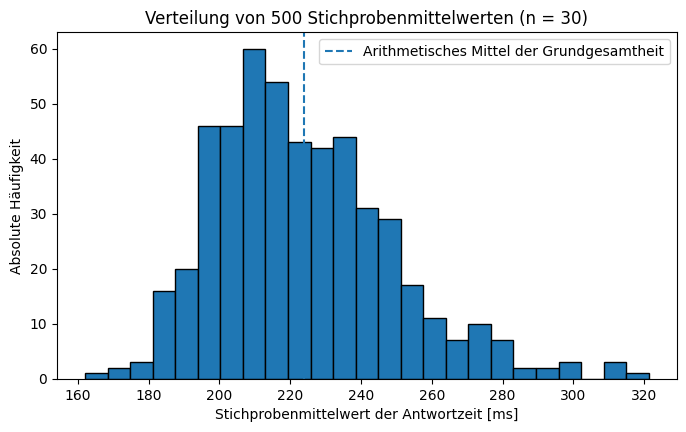

In [27]:
sample_means.plot.hist(bins=25, edgecolor="black")
plt.axvline(
    response_data["response_ms"].mean(),
    linestyle="--",
    label="Arithmetisches Mittel der Grundgesamtheit"
)
plt.title("Verteilung von 500 Stichprobenmittelwerten (n = 30)")
plt.xlabel("Stichprobenmittelwert der Antwortzeit [ms]")
plt.ylabel("Absolute Häufigkeit")
plt.legend()
plt.show()

Die Stichprobenmittelwerte sind nicht identisch, obwohl alle Stichproben aus derselben Grundgesamtheit gezogen werden. Die Stichprobenmittelwerte unterliegen also einer **zufälligen Schwankung**.

In [28]:
def repeated_means(n, repetitions=500, seed=123):
    local_rng = np.random.default_rng(seed)
    means = []
    for _ in range(repetitions):
        sample = response_data["response_ms"].sample(
            n=n,
            replace=False,
            random_state=int(local_rng.integers(1_000_000))
        )
        means.append(sample.mean())
    return pd.Series(means)

comparison = pd.DataFrame({
    "n=10": repeated_means(10),
    "n=30": repeated_means(30),
    "n=100": repeated_means(100),
})

comparison.std().round(1)

n=10     43.7
n=30     23.5
n=100    11.6
dtype: float64

In dieser Simulation nimmt die Standardabweichung der Stichprobenmittelwerte mit zunehmendem Stichprobenumfang ab. Größere Zufallsstichproben liefern daher im Allgemeinen präzisere Schätzungen eines Mittelwerts, sofern das verwendete Stichprobenverfahren und die zugrunde liegenden Annahmen angemessen sind.

## 11. Abschlussaufgaben

Beantworten Sie die folgenden Fragen zunächst mit Python und formulieren Sie anschließend jeweils eine kurze statistische Aussage.

1. Welcher Endpoint hat den größten Median der Antwortzeit?
2. Wie groß ist die relative Häufigkeit der Requests mit Statuscode 500?
3. Welche Region hat den größten Median der Antwortzeit?
4. Formulieren Sie zu Aufgabe 3 eine rein deskriptive Aussage, ohne eine Ursache für den Unterschied zu behaupten.

In [29]:
median_by_endpoint = (
    response_data.groupby("endpoint")["response_ms"]
    .median()
    .sort_values(ascending=False)
)
median_by_endpoint

endpoint
/checkout    296.10
/cart        207.20
/search      197.15
/product     189.50
/login       148.60
Name: response_ms, dtype: float64

In [30]:
share_500 = df["status_code"].eq(500).mean() * 100
print(f"Relative Häufigkeit HTTP 500: {share_500:.1f} %")

Relative Häufigkeit HTTP 500: 4.1 %


In [31]:
median_by_region = (
    response_data.groupby("region")["response_ms"]
    .median()
    .sort_values(ascending=False)
)
median_by_region

region
US-East       273.0
EU-West       192.7
EU-Central    172.0
Name: response_ms, dtype: float64

Eine sachlich korrekte Formulierung zu Aufgabe 3 lautet beispielsweise:

> Unter den beobachteten Requests mit gemessener Antwortzeit weist die Region `US-East` den größten Median der Antwortzeit auf.

Aus dieser deskriptiven Auswertung folgt nicht, dass die Region die höheren Antwortzeiten verursacht.

### Beurteilung statistischer Aussagen

A ist durch die deskriptive Auswertung gerechtfertigt.

B ist nicht gerechtfertigt. Für eine kausale Interpretation reicht der einfache Gruppenvergleich nicht aus.

C ist nicht gerechtfertigt. Ein Pearson-Korrelationskoeffizient nahe null bedeutet lediglich, dass kein ausgeprägter linearer Gesamtzusammenhang vorliegt.

## 12. Zusammenfassung

- Statistische Auswertungen beginnen mit der Festlegung von Grundgesamtheit, Merkmalen und Ausprägungen.
- Die Merkmalsskalierung bestimmt, welche Kennzahlen und Darstellungen sinnvoll sind.
- Fehlende Werte sollten in Abhängigkeit von der jeweiligen Fragestellung behandelt werden.
- Arithmetisches Mittel und Median sind Lagemaße mit unterschiedlichen Eigenschaften.
- Empirische Standardabweichung und Interquartilsabstand beschreiben die Streuung.
- Histogramm und Boxplot beschreiben die Verteilung eines metrischen Merkmals auf unterschiedliche Weise.
- Gruppenunterschiede und Korrelationen sind zunächst deskriptive Befunde.
- Aus einem statistischen Zusammenhang folgt nicht ohne Weiteres ein kausaler Zusammenhang.
- Kennzahlen aus Zufallsstichproben unterliegen zufälligen Schwankungen.

# Hinweise zur Durchführung

## Zeitlicher Ablauf für etwa 75 bis 90 Minuten

| Zeit | Inhalt |
|---:|---|
| 0–10 min | Untersuchungsgegenstand, Grundgesamtheit, Merkmale, Merkmalsskalierungen |
| 10–20 min | Datensatz prüfen, fehlende Werte, Filtern |
| 20–30 min | Absolute und relative Häufigkeiten |
| 30–45 min | Lage- und Streuungsmaße, Histogramm, Boxplot |
| 45–60 min | Gruppenvergleich nach Endpoint und Cache-Hit |
| 60–70 min | Streudiagramm und Pearson-Korrelation |
| 70–80 min | zufällige Schwankung der Stichprobenmittelwerte |
| verbleibende Zeit | Abschlussaufgaben und Diskussion |

## Geeignete Diskussionsfragen

1. Warum ist das arithmetische Mittel für `status_code` nicht sinnvoll, obwohl die Ausprägungen als Zahlen gespeichert sind?
2. Warum wird für die Endpoint-Häufigkeiten `df`, für Auswertungen der Antwortzeit aber `response_data` verwendet?
3. Sind Beobachtungen außerhalb der Boxplot-Whisker automatisch Messfehler?
4. Was ist der Unterschied zwischen der Aussage „Requests mit Cache-Hit haben geringere Antwortzeiten“ und einer kausalen Aussage über die Wirkung des Cachings?
5. Was lässt sich aus einem Pearson-Korrelationskoeffizienten nahe null ableiten, und was nicht?
6. Warum unterscheiden sich arithmetische Mittel verschiedener Zufallsstichproben aus derselben Grundgesamtheit?

Bei knapper Zeit kann die gruppenweise Korrelationsanalyse entfallen. Die Stichprobensimulation kann dann auf den Fall $n=30$ beschränkt werden.